**Data Collection & Overview**_(Phân tích khám phá dữ liệu)

In [ ]:
#Import & đọc dữ
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
#Import & đọc dữ
from google.colab import files
uploaded = files.upload()

Saving bank.csv to bank.csv


**Verify data size**

In [ ]:
import pandas as pd
df = pd.read_csv("bank.csv")
df.shape

(11162, 17)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('bank.csv')

In [ ]:
import pandas as pd
df = pd.read_csv("bank.csv")
print("Shape:", df.shape)
df.head()

Shape: (11162, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [ ]:
df.groupby('deposit')['duration'].describe()

,count,mean,std,min,25%,50%,75%,max
deposit,,,,,,,,
no,5873.0,223.130257,208.577530,2.0,94.0,163.0,282.0,3284.0
yes,5289.0,537.294574,392.525262,8.0,244.0,426.0,725.0,3881.0


In [ ]:
import pandas as pd
df = pd.read_csv("bank.csv") # Reload df to ensure original 'yes'/'no' values
conversion_rate = df['deposit'].map({'yes':1,'no':0}).mean()
print("Baseline conversion rate:", conversion_rate)

# Hypothetical example
call_cost = 1.2      # USD per call
profit_per_conversion = 50

expected_profit_random = conversion_rate * profit_per_conversion - call_cost
expected_profit_random

Baseline conversion rate: 0.4738398136534671


np.float64(22.491990682673357)

In [ ]:
import pandas as pd
df = pd.read_csv("bank.csv")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
if 'y' in df.columns:
    print(df['y'].value_counts(normalize=True))
else:
    for col in df.columns:
        vals = df[col].dropna().unique()
        if set(map(str.lower, map(str, vals))).intersection({'yes','no'}):
            print(f"Possible target column: {col}")
            print(df[col].value_counts(normalize=True))
        elif df[col].nunique() == 2:
            print(f"Binary column (2 unique values) candidate: {col} -> {df[col].value_counts()}")

Shape: (11162, 17)
Columns: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'deposit']
Possible target column: default
default
no     0.984949
yes    0.015051
Name: proportion, dtype: float64
Possible target column: housing
housing
no     0.526877
yes    0.473123
Name: proportion, dtype: float64
Possible target column: loan
loan
no     0.869199
yes    0.130801
Name: proportion, dtype: float64
Possible target column: deposit
deposit
no     0.52616
yes    0.47384
Name: proportion, dtype: float64


In [ ]:
print(df.head())
if 'month' in df.columns:
    print("Months:", sorted(df['month'].dropna().unique()))
if 'day' in df.columns:
    print("Day sample:", df['day'].unique()[:10])

   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day month  duration  campaign  pdays  previous poutcome deposit  
0    5   may      1042         1     -1         0  unknown     yes  
1    5   may      1467         1     -1         0  unknown     yes  
2    5   may      1389         1     -1         0  unknown     yes  
3    5   may       579         1     -1         0  unknown     yes  
4    5   may       673         2     -1         0  unknown     yes  
Months: ['apr', 'aug', 'dec', 'feb', 'jan', 'jul', 'jun', 'mar', 'may', 'nov', 'oct', 'sep']
Day sa

In [ ]:
df[['duration', 'campaign', 'previous']].head()

,duration,campaign,previous
0,1042,1,0
1,1467,1,0
2,1389,1,0
3,579,1,0
4,673,2,0


In [ ]:
df.columns.tolist()

['age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'contact',
 'day',
 'month',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'deposit']

In [ ]:
df['month'].unique()[:6], df['day'].head()

(array(['may', 'jun', 'jul', 'aug', 'oct', 'nov'], dtype=object),
 0    5
 1    5
 2    5
 3    5
 4    5
 Name: day, dtype: int64)

In [ ]:
print("Duplicates:", df.duplicated().sum())
print("Missing per column:")
print(df.isna().sum().sort_values(ascending=False).head(10))

Duplicates: 0
Missing per column:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
dtype: int64


III- (Data Collecting & Preprocessing).

In [ ]:
import pandas as pd

df = pd.read_csv("bank.csv")
print("Data size:", df.shape)
df.head()


Data size: (11162, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [ ]:
import pandas as pd
df = pd.read_csv("bank.csv")
print("Shape:", df.shape)
df.info()
df.head()

Shape: (11162, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [ ]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [ ]:
df.groupby('deposit')['duration'].median()

,duration
deposit,
no,163.0
yes,426.0


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import OneHotEncoder

# Prepare one-hot encoded df for VIF
df_enc = pd.get_dummies(df.drop(columns=['duration','deposit']), drop_first=True)

# Convert boolean columns to int to avoid TypeError with statsmodels
for col in df_enc.select_dtypes(include='bool').columns:
    df_enc[col] = df_enc[col].astype(int)

vif_df = pd.DataFrame()
vif_df["feature"] = df_enc.columns
vif_df["VIF"] = [variance_inflation_factor(df_enc.values, i) for i in range(df_enc.shape[1])]
vif_df.sort_values('VIF', ascending=False).head(10)

,feature,VIF
0,age,18.669255
40,poutcome_unknown,17.537692
17,marital_married,5.445850
2,day,5.356792
20,education_tertiary,4.931533
19,education_secondary,4.875445
34,month_may,4.486054
9,job_management,3.876547
18,marital_single,3.693818
4,pdays,3.584231


In [ ]:
from sklearn.preprocessing import StandardScaler

num_cols = ['age','balance','day','campaign','pdays','previous']
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

In [ ]:
df = pd.get_dummies(df, columns=['job', 'marital', 'education', 'poutcome'], drop_first=True)

In [ ]:
bins = [0,25,35,45,55,65,120]
labels = ['<25','25-35','35-45','45-55','55-65','65+']

df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

# Ensure 'deposit' column is mapped to numerical 0/1 for consistency
# This step is often done later, but needed here for immediate use of df['deposit'].value_counts()
if df['deposit'].dtype == 'object':
    df['deposit'] = df['deposit'].map({'yes': 1, 'no': 0})

In [ ]:
df['deposit'].value_counts(normalize=True)

,proportion
deposit,
no,0.52616
yes,0.47384


In [ ]:
df['deposit'].value_counts(normalize=True)

,proportion
deposit,
no,0.52616
yes,0.47384


In [ ]:
df.to_csv('/content/bank_clean_model_ready.csv', index=False)

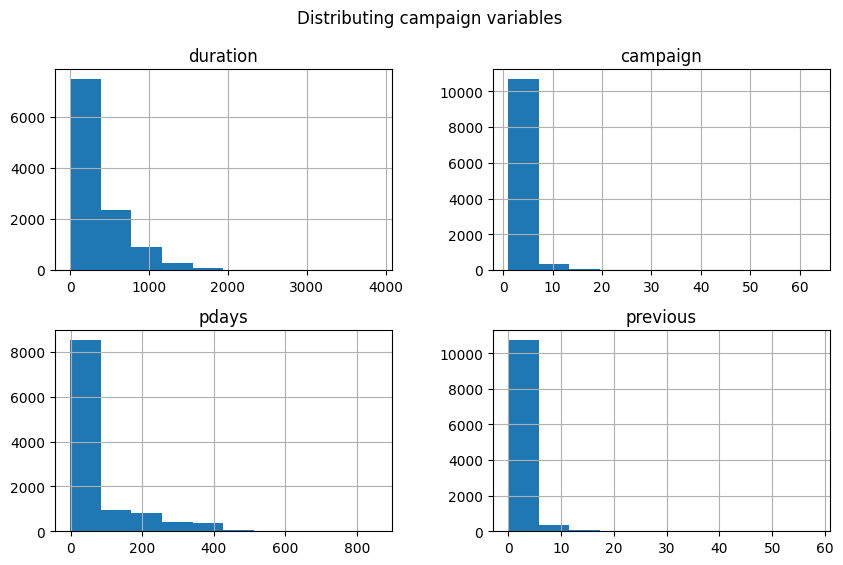

In [ ]:
cols = ['duration', 'campaign', 'pdays', 'previous']
df[cols].hist(figsize=(10,6))
plt.suptitle("Distributing campaign variables")
plt.show()


**IV- Exploratory Data Analysis (EDA)**

In [ ]:
import pandas as pd
df = pd.read_csv("bank.csv")
df['deposit'] = df['deposit'].map({'yes': 1, 'no': 0})

top_10 = (df.groupby('job')['deposit'].mean()*100).sort_values(ascending=False).head(10)
bot_10 = (df.groupby('job')['deposit'].mean()*100).sort_values(ascending=False).tail(10)
top_10.to_excel("Top 10 jobs by conversion rate.xlsx")
bot_10.to_excel("Bottom 10 jobs by conversion rate.xlsx")

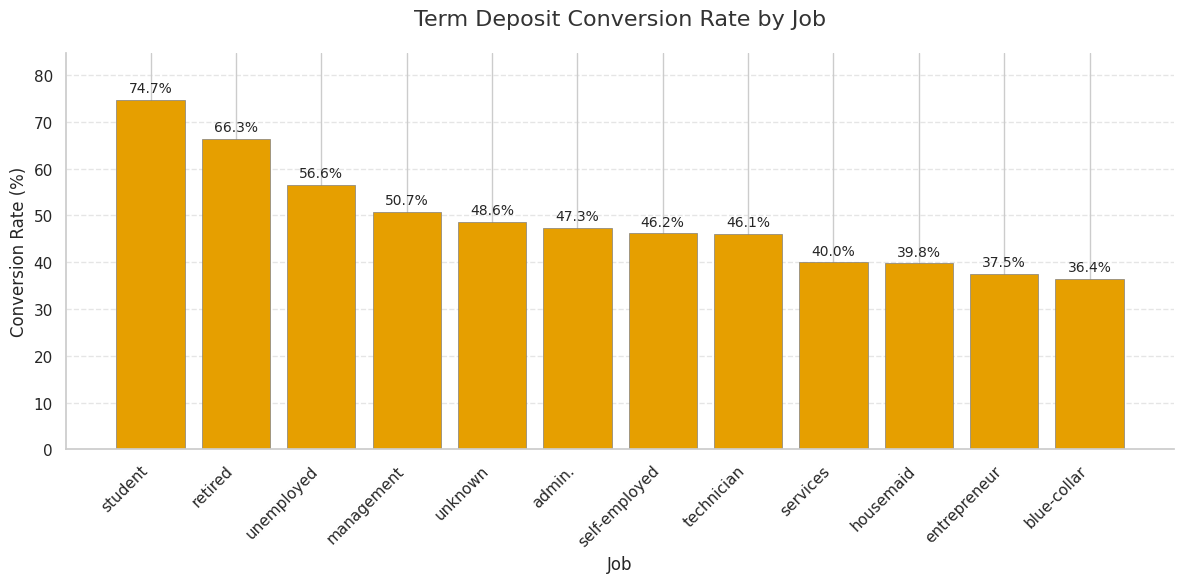

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('bank.csv')
df['conversion'] = df['deposit'].apply(lambda x: 1 if x == 'yes' else 0)

job_conversion = df.groupby('job')['conversion'].mean() * 100
job_conversion = job_conversion.sort_values(ascending=False)
plt.figure(figsize=(12, 6))

bars = plt.bar(job_conversion.index, job_conversion.values,
               color='#E69F00', edgecolor='grey', linewidth=0.5)
plt.title('Term Deposit Conversion Rate by Job', fontsize=16, pad=20, color='#333333')
plt.ylabel('Conversion Rate (%)', fontsize=12)
plt.xlabel('Job', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.ylim(0, max(job_conversion.values) + 10) # Set limit slightly higher than max value
plt.xticks(rotation=45, ha='right')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=10)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
obj_des = df[['job','marital','education','deposit']].describe(include='object')
obj_des.to_excel("object_describe.xlsx", index=False)

In [ ]:
df[['age']].describe().T.to_excel("describe_age.xlsx")

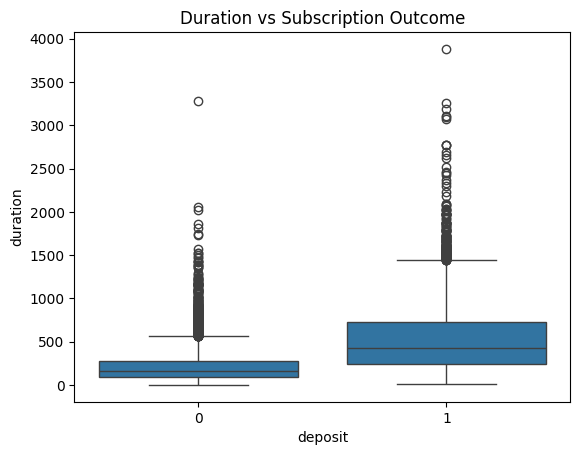

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(x=df['deposit'], y=df['duration'])
plt.title("Duration vs Subscription Outcome")
plt.show()

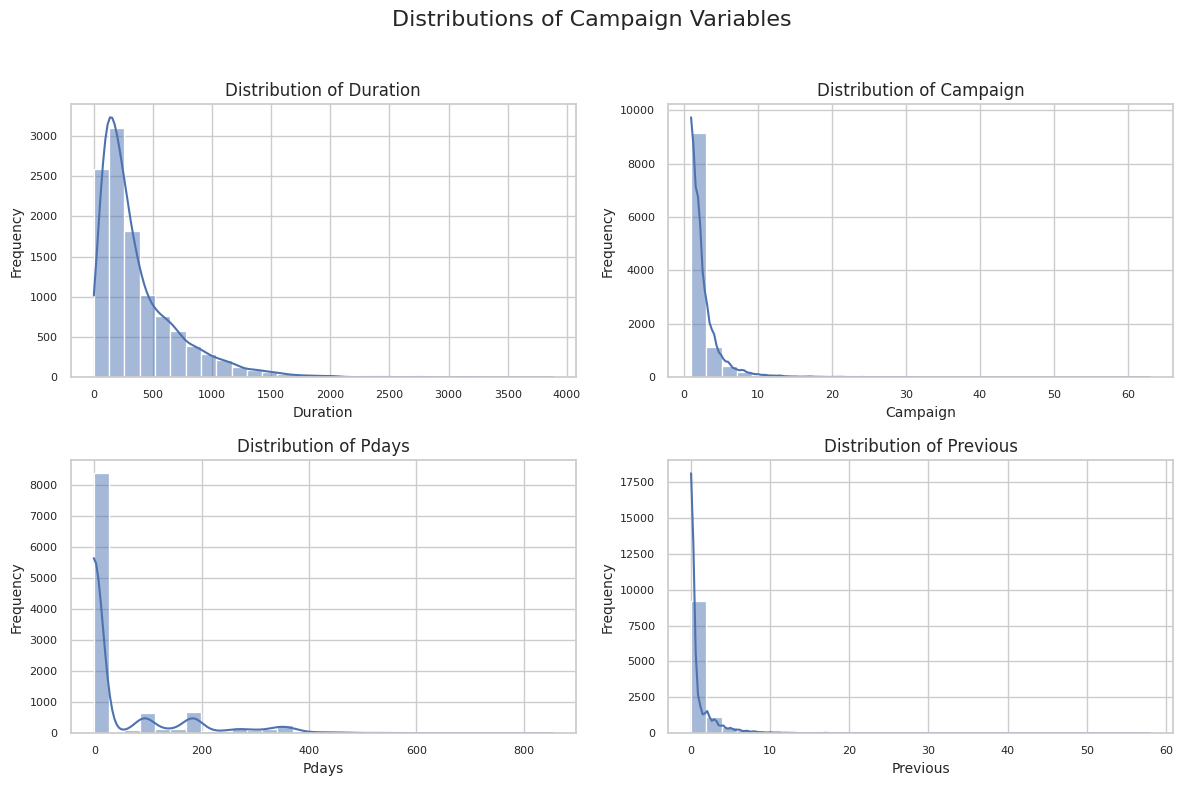

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['duration', 'campaign', 'pdays', 'previous']

# Create a grid of subplots
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
fig.suptitle("Distributions of Campaign Variables", fontsize=16)
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(df[col], kde=True, ax=axes[i], bins=30) # kde=True for density curve
    axes[i].set_title(f'Distribution of {col.capitalize()}', fontsize=12)
    axes[i].set_xlabel(col.capitalize(), fontsize=10)
    axes[i].set_ylabel('Frequency', fontsize=10)
    axes[i].tick_params(axis='both', which='major', labelsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust rect to make space for suptitle
plt.show()

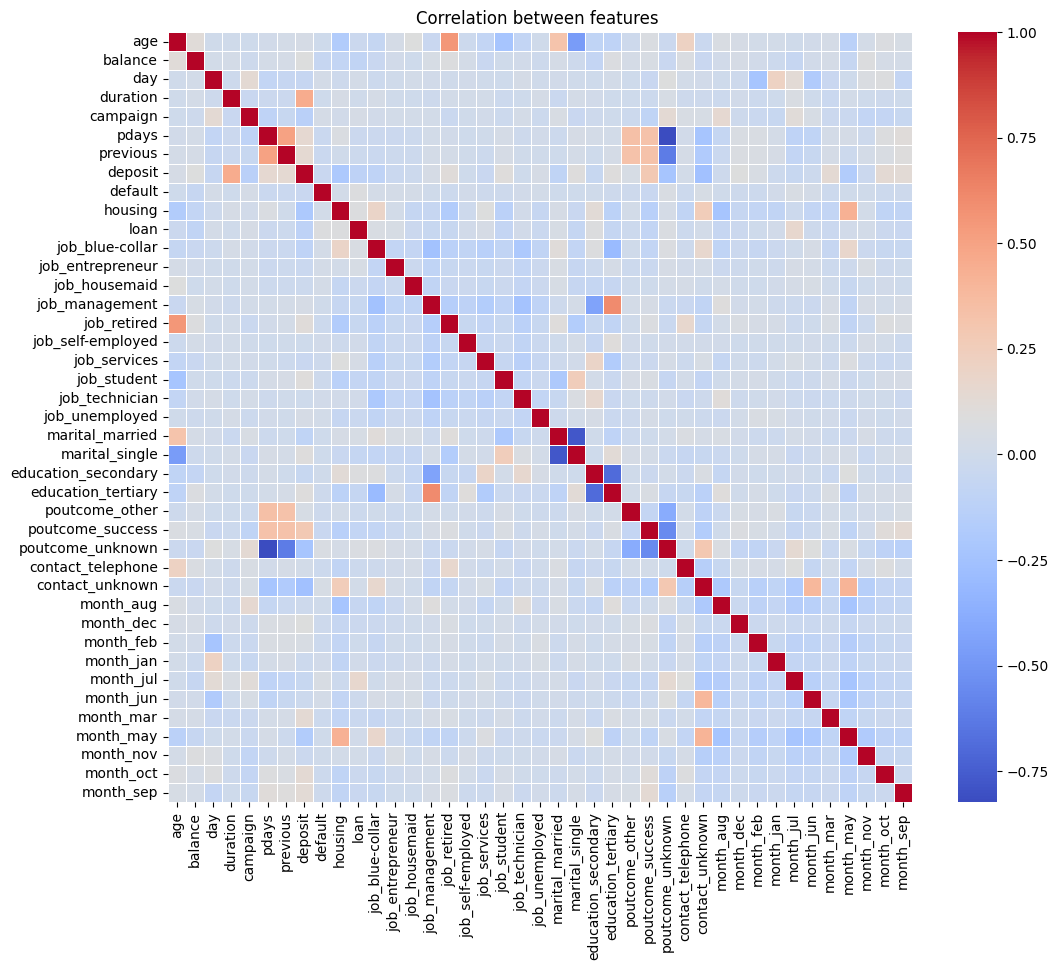

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df_corr_subset.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, fmt=".2f",
            linewidths=0.5, linecolor='white')
plt.title('Correlation between features ')
plt.show()

In [ ]:
df.columns = df.columns.str.lower().str.strip()

cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = df[col].str.lower().str.strip()

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


**Feature Engineer**_ Kỹ thuật đặc trưng

In [ ]:
# Feature Engineering for Modeling
# 1. Age grouping (non-linear relation)
df['age_group'] = pd.cut(df['age'], bins=[0, 25,35,45,55,65,120],
                         labels=['<25','25-35','35-45','45-55','55-65','65+'])

# 2. One- hot encoding categorical variables
df_model = pd.get_dummies(df, columns=['job', 'marital', 'education', 'poutcome', 'age_group'],
                          drop_first=True)

# 3. Target encoding (optional - bonus point)
df_model['deposit'] = df_model['deposit'].map({'yes': 1, 'no': 0})

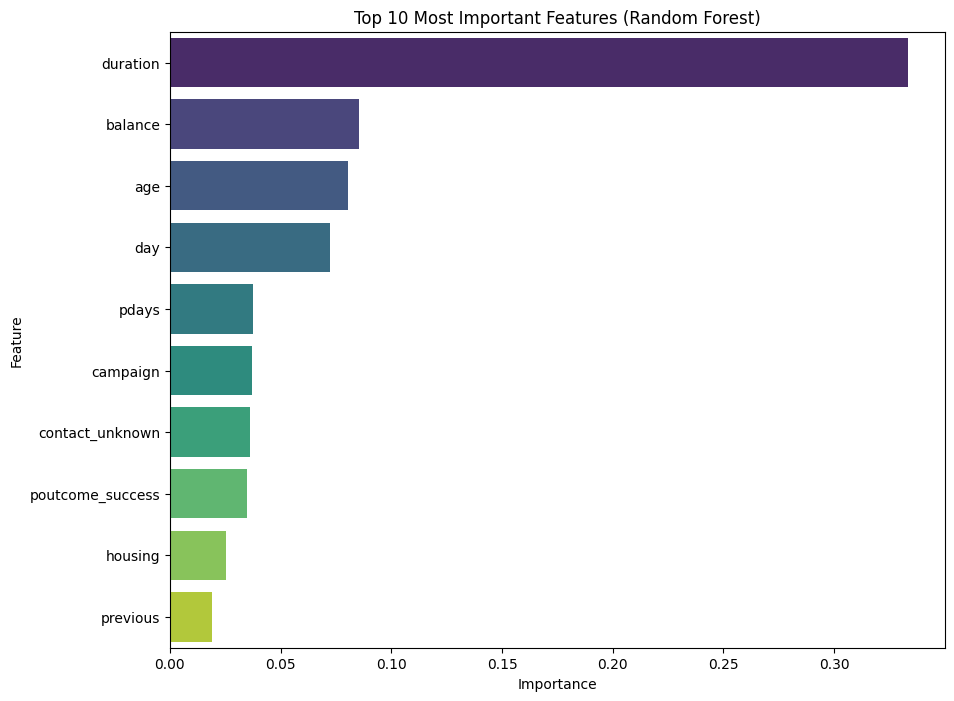

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Re-load data and re-process to ensure X, X_train, and best_model are defined
# (These steps are copied from cell z4bMtUea_gtY to make this cell runnable independently)

df = pd.read_csv("bank.csv")

df["deposit"] = df["deposit"].map({"yes" :1, "no" :0})
df["default"] = df["default"].map({"yes" :1, "no" :0})
df["housing"] = df["housing"].map({"yes" :1, "no" :0})
df["loan"] = df["loan"].map({"yes" :1, "no" :0})
df_encoded = pd.get_dummies(df, drop_first = True)

X = df_encoded.drop("deposit", axis = 1)
y= df_encoded["deposit"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify=y)

# Re-initialize and train the best model (Random Forest, as determined previously)
best_model = RandomForestClassifier(n_estimators=100, random_state=42)
best_model.fit(X_train, y_train)

feature_names = X.columns
importances = best_model.feature_importances_

feature_importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importances.head(10), x='Importance', y='Feature', palette='viridis')
plt.title("Top 10 Most Important Features (Random Forest)")
plt.show()


In [ ]:
import pandas as pd
from scipy.stats import chi2_contingency, ttest_ind # Added ttest_ind import

def run_chi_square_tests(df, categorical_vars, target_var='deposit'):
    """Thực hiện kiểm định Chi-Square và trả về DataFrame kết quả."""
    results = []

    for var in categorical_vars:
        contingency_table = pd.crosstab(df[var], df[target_var])
        try:
            chi2, p_value, _, _ = chi2_contingency(contingency_table)

            # Kiểm tra p-value để đưa ra kết luận
            conclusion = "Strong relationship" if p_value < 0.001 else ("Significant" if p_value < 0.05 else "No significant relationship")

            results.append({
                'Variable': var,
                'Chi-Square': f"{chi2:.3f}",
                'p-value': f"{p_value:.5f}" if p_value >= 0.00001 else "<0.001",
                'Conclusion': conclusion
            })
        except ValueError:
            results.append({
                'Variable': var,
                'Chi-Square': 'N/A',
                'p-value': 'N/A',
                'Conclusion': 'Error: Insufficient data or low cell count'
            })

    return pd.DataFrame(results)

def run_t_test(df, numerical_var, target_var='deposit'):
    """Thực hiện kiểm định T-Test độc lập và trả về DataFrame kết quả."""
    # Assuming target_var is binary (0 or 1)
    group_1 = df[df[target_var] == 1][numerical_var]
    group_0 = df[df[target_var] == 0][numerical_var]

    # Perform independent T-Test (assuming unequal variances: equal_var=False)
    t_stat, p_value = ttest_ind(group_1, group_0, equal_var=False, nan_policy='omit')

    # Check p-value for conclusion
    conclusion = "Significant" if p_value < 0.05 else "Not significant"

    # Create results DataFrame
    t_test_df = pd.DataFrame({
        'Test': [f'{numerical_var} vs {target_var} (1/0)'],
        't-stat': [f"{t_stat:.3f}"],
        'p-value': [f"{p_value:.5f}" if p_value >= 0.00001 else "<0.001"],
        'Conclusion': [conclusion]
    })
    return t_test_df

# Re-load data to ensure 'deposit' is in the correct format (0/1)
df = pd.read_csv("bank.csv")
df["deposit"] = df["deposit"].map({"yes" :1, "no" :0})

# Chạy kiểm định Chi-Square
categorical_vars = ['job', 'marital', 'education']
chi_square_results = run_chi_square_tests(df, categorical_vars)
print("--- Chi-Square Test Result (Job, Marital, Education -> Deposit) ---")
print(chi_square_results.to_markdown(index=False))

# Chạy kiểm định T-Test cho tuổi
t_test_results = run_t_test(df, 'age')
print("\n--- T-Test for Age ---")
print(t_test_results.to_markdown(index=False))

--- Chi-Square Test Result (Job, Marital, Education -> Deposit) ---
| Variable   |   Chi-Square | p-value   | Conclusion          |
|:-----------|-------------:|:----------|:--------------------|
| job        |      378.075 | <0.001    | Strong relationship |
| marital    |      109.583 | <0.001    | Strong relationship |
| education  |      122.77  | <0.001    | Strong relationship |

--- T-Test for Age ---
| Test                 |   t-stat |   p-value | Conclusion   |
|:---------------------|---------:|----------:|:-------------|
| age vs deposit (1/0) |    3.638 |   0.00028 | Significant  |


In [ ]:
from scipy.stats import chi2_contingency

categorical_vars = ['job', 'marital', 'education']

print("Chi-Square Test Results:")
for var in categorical_vars:
    # Create a contingency table
    contingency_table = pd.crosstab(df[var], df['deposit'])

    # Perform the Chi-Square test
    chi2, p_value, _, _ = chi2_contingency(contingency_table)

    print(f"\nVariable: {var}")
    print(f"Chi-Square: {chi2:.2f}, p-value: {p_value:.5f}")
    if p_value < 0.05:
        print("Conclusion: Strong relationship (Reject Null Hypothesis)")
    else:
        print("Conclusion: No significant relationship")

Chi-Square Test Results:

Variable: job
Chi-Square: 378.08, p-value: 0.00000
Conclusion: Strong relationship (Reject Null Hypothesis)

Variable: marital
Chi-Square: 109.58, p-value: 0.00000
Conclusion: Strong relationship (Reject Null Hypothesis)

Variable: education
Chi-Square: 122.77, p-value: 0.00000
Conclusion: Strong relationship (Reject Null Hypothesis)


**V- Model building**

Data size: (11162, 17)
   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day month  duration  campaign  pdays  previous poutcome deposit  
0    5   may      1042         1     -1         0  unknown     yes  
1    5   may      1467         1     -1         0  unknown     yes  
2    5   may      1389         1     -1         0  unknown     yes  
3    5   may       579         1     -1         0  unknown     yes  
4    5   may       673         2     -1         0  unknown     yes  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161


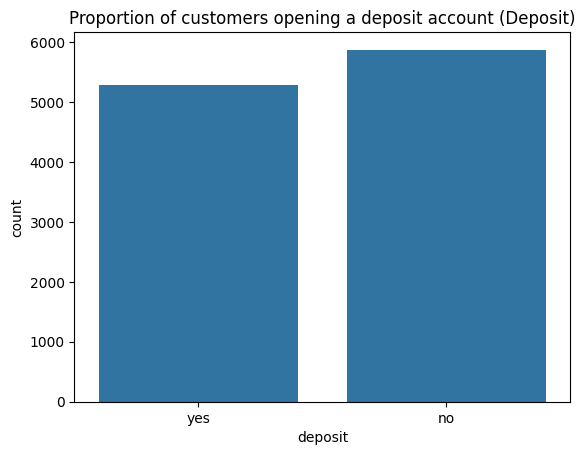

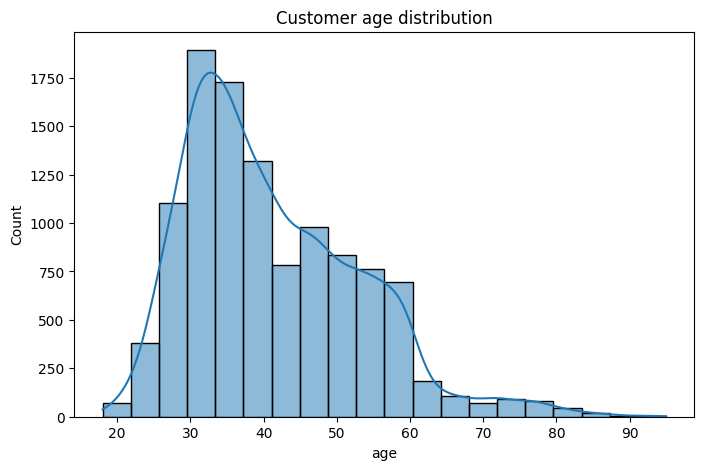

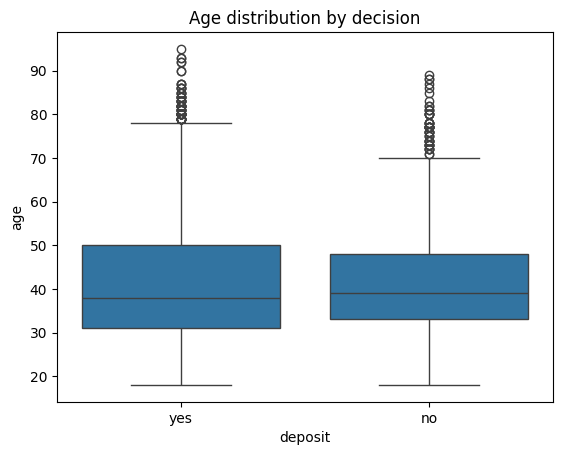

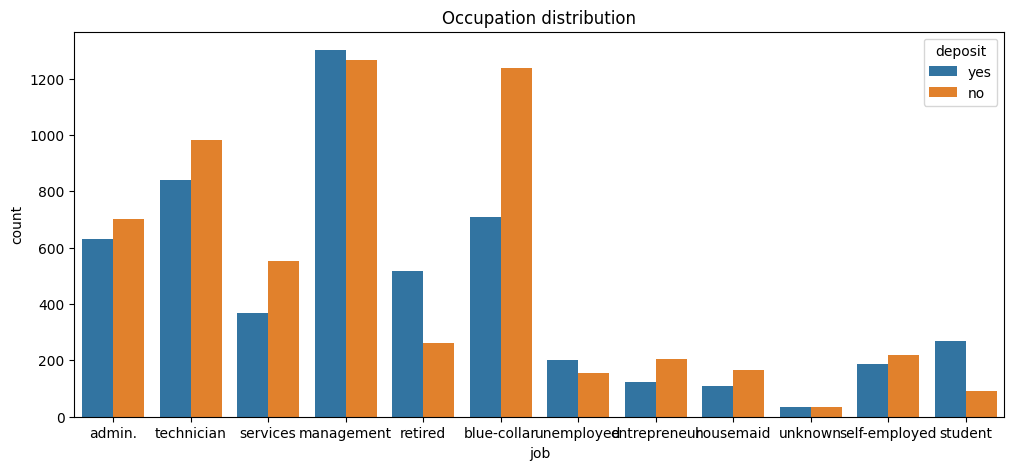

Data size after encoding: (11162, 43)
Train size: (8929, 42)
Test size: (2233, 42)

=== Logistic Regression ===
Accuracy: 0.824
Confusion Matrix:
 [[989 186]
 [207 851]]
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.84      0.83      1175
           1       0.82      0.80      0.81      1058

    accuracy                           0.82      2233
   macro avg       0.82      0.82      0.82      2233
weighted avg       0.82      0.82      0.82      2233


=== Decision Tree ===
Accuracy: 0.813
Confusion Matrix:
 [[982 193]
 [225 833]]
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.84      0.82      1175
           1       0.81      0.79      0.80      1058

    accuracy                           0.81      2233
   macro avg       0.81      0.81      0.81      2233
weighted avg       0.81      0.81      0.81      2233


=== Random Forest ===
Accuracy: 0.858
Confusio

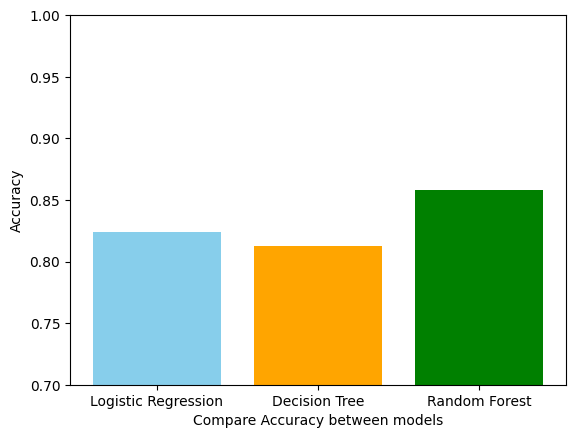


The best model: Random Forest with precision85.8%

Best model: Random Forest with accuracy = 0.858

Top 10 important features:
duration            0.333332
balance             0.085417
age                 0.080643
day                 0.072267
pdays               0.037692
campaign            0.036902
contact_unknown     0.036086
poutcome_success    0.034950
housing             0.025288
previous            0.018812
dtype: float64


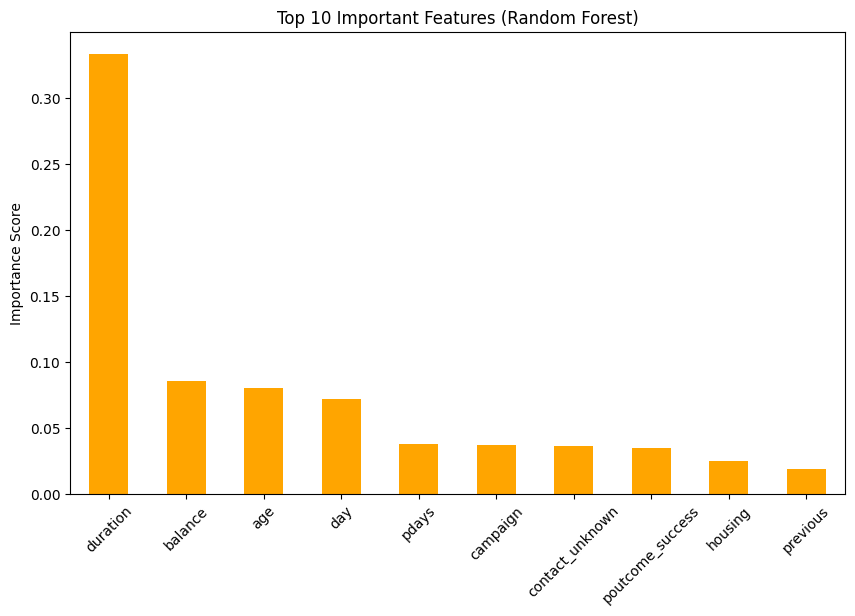

In [ ]:
#Bước 1: Thư viện cơ bản
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Bước 2 Đọc dữ liệu
df = pd.read_csv("bank.csv")
print("Data size:", df.shape)
print(df.head())
print(df.info())

#Bước 3: Kiểm tra thông tin và missing_ KHÁM PHÁ DỮ LIỆU (EDA)
print("\nMissing values:\n", df.isnull().sum())
print("\nTarget Distribution:\n", df["deposit"].value_counts())
sns.countplot(x="deposit", data=df)
plt.title("Proportion of customers opening a deposit account (Deposit)")
plt.show()

# Phân tích độ tuổi
plt.figure(figsize=(8,5))
sns.histplot(df["age"], bins=20, kde=True)
plt.title("Customer age distribution")
plt.show()

sns.boxplot(x="deposit", y="age", data=df)
plt.title("Age distribution by decision")
plt.show()

# Phân tích theo nghề nghiệp
plt.figure(figsize=(12,5))
sns.countplot(x="job", hue="deposit", data=df)
plt.title("Occupation distribution")
plt.show()

# Bước 3: Tiền xử lý dữ liệu
df["deposit"] = df["deposit"].map({"yes" :1, "no" :0})
df["default"] = df["default"].map({"yes" :1, "no" :0})
df["housing"] = df["housing"].map({"yes" :1, "no" :0})
df["loan"] = df["loan"].map({"yes" :1, "no" :0})
df_encoded = pd.get_dummies(df, drop_first = True)
print("Data size after encoding:", df_encoded.shape)


# Bước 4: Chia dữ liệu train/
from sklearn.model_selection import train_test_split
X = df_encoded.drop("deposit", axis = 1)
y= df_encoded["deposit"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify=y)
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

# Bước 5: Mô hình
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings("ignore")

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"\n=== {name} ===")
    print("Accuracy:", round(acc, 3))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))

# So sánh kết quả giữa các mô hình
plt.bar(results.keys(), results.values(), color=["skyblue", "orange", "green"])
plt.xlabel("Compare Accuracy between models")
plt.ylabel("Accuracy")
plt.ylim(0.7, 1)
plt.show()

# Bước 6: Đánh giá và kết luận
best_model = max(results, key=results.get)
print(f"\nThe best model: {best_model} with precision{round(results[best_model]*100, 2)}%")

# Phân tích đặc trưng quan trọng
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]   # Gán chính mô hình thật vào biến
best_model.fit(X_train, y_train)       # Huấn luyện lại model tốt nhất trên tập train

print(f"\nBest model: {best_model_name} with accuracy = {results[best_model_name]:.3f}")

# --- Nếu model tốt nhất là Random Forest thì phân tích đặc trưng quan trọng ---
if best_model_name == "Random Forest":
    importances = best_model.feature_importances_
    feature_names = X.columns

    feat_importance = pd.Series(importances, index=feature_names).sort_values(ascending=False)
    print("\nTop 10 important features:")
    print(feat_importance.head(10))

    # Biểu đồ đặc trưng quan trọng
    plt.figure(figsize=(10,6))
    feat_importance.head(10).plot(kind='bar', color='orange')
    plt.title('Top 10 Important Features (Random Forest)')
    plt.ylabel('Importance Score')
    plt.xticks(rotation=45)
    plt.show()
else:
    print(f"Mô hình {best_model_name} không có thuộc tính feature_importances_.")


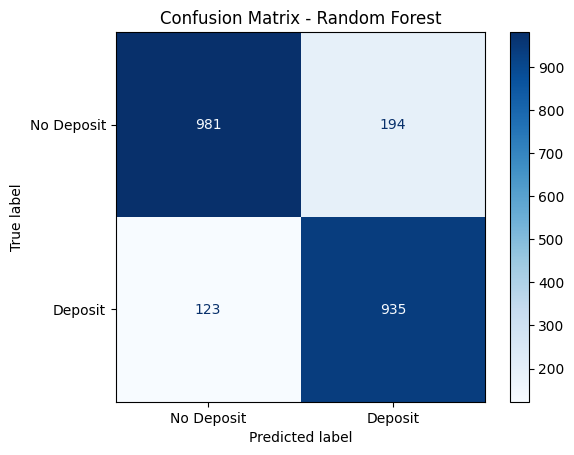

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Deposit", "Deposit"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.show()

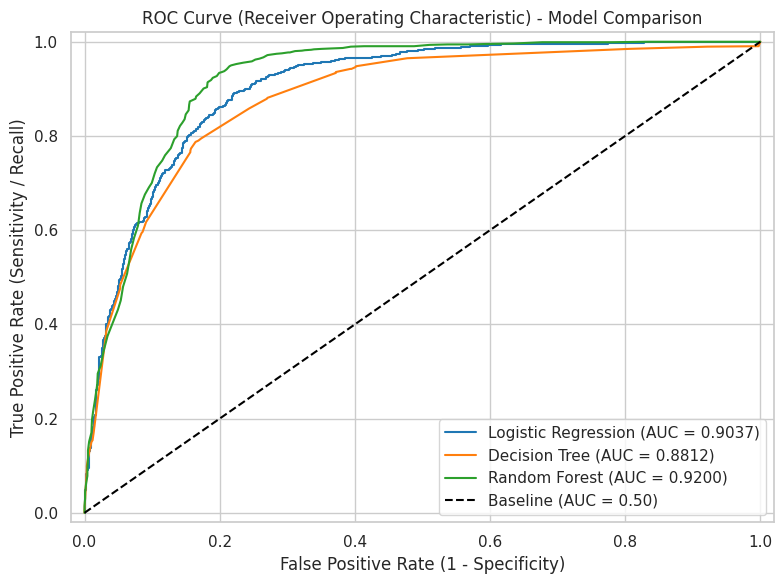

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# --- Re-run necessary preprocessing and model training to ensure consistent state ---
# (Copied from z4bMtUea_gtY to make this cell self-contained and avoid feature mismatch)
df = pd.read_csv("bank.csv")
df["deposit"] = df["deposit"].map({"yes" :1, "no" :0})
df["default"] = df["default"].map({"yes" :1, "no" :0})
df["housing"] = df["housing"].map({"yes" :1, "no" :0})
df["loan"] = df["loan"].map({"yes" :1, "no" :0})
df_encoded = pd.get_dummies(df, drop_first = True)

X = df_encoded.drop("deposit", axis = 1)
y= df_encoded["deposit"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify=y)

# Re-initialize and train models (as done in z4bMtUea_gtY)
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42), # Added random_state for reproducibility
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
# --- End of re-run preprocessing and model training ---


# Get trained models from the 'models' dictionary
model_lr = models["Logistic Regression"]
model_dt = models["Decision Tree"]
model_rf = models["Random Forest"]

# Calculate probability predictions for the positive class
y_score_lr = model_lr.predict_proba(X_test)[:, 1]
y_score_dt = model_dt.predict_proba(X_test)[:, 1]
y_score_rf = model_rf.predict_proba(X_test)[:, 1]

# 1. Tính toán FPR, TPR và AUC cho từng mô hình từ dữ liệu thật
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_score_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

fpr_dt, tpr_dt, _ = roc_curve(y_test, y_score_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_score_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# 2. Vẽ biểu đồ
plt.figure(figsize=(8, 6))

# Vẽ đường cho từng mô hình với chỉ số AUC tính toán được
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_lr:.4f})', color='tab:blue', linewidth=1.5)
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {roc_auc_dt:.4f})', color='tab:orange', linewidth=1.5)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.4f})', color='tab:green', linewidth=1.5)

# Vẽ đường Baseline (đường chéo)
plt.plot([0, 1], [0, 1], color='black', linestyle='--', label='Baseline (AUC = 0.50)')

# 3. Định dạng biểu đồ giống hệt ảnh mẫu
plt.title('ROC Curve (Receiver Operating Characteristic) - Model Comparison')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity / Recall)')
plt.grid(True)
plt.legend(loc='lower right')

# Giới hạn trục để biểu đồ thoáng hơn
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])

# Hiển thị ảnh
plt.tight_layout()
plt.show()

In [ ]:
# Job vs Deposit
job_conv = pd.crosstab(df['job'], df['deposit'], normalize='index')*100
job_conv.to_excel("Job_vs_Deposit_Conversion.xlsx")

# Marital vs Deposit
marital_conv = pd.crosstab(df['marital'], df['deposit'], normalize='index')*100
marital_conv.to_excel("Marital_vs_Deposit_Conversion.xlsx")

# Education vs Deposit
edu_conv = pd.crosstab(df['education'], df['deposit'], normalize='index')*100
edu_conv.to_excel("Education_vs_Deposit_Conversion.xlsx")

**1234**

In [ ]:
# Train-Test Split with Scikit-Learn
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Training the Winning Model
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

RandomForestClassifier()

**Visualizing SHAP:**

In [ ]:
pip install shap matplotlib scikit-learn pandas

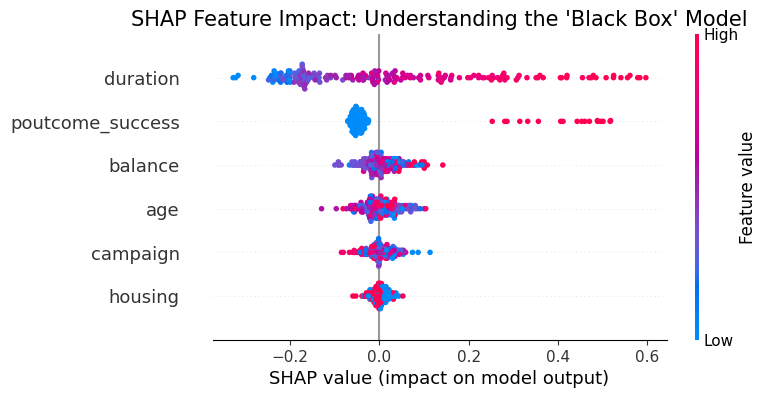

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# 1. Simulated data (Replace with new Bank Marketing data)
data = {
    'duration': np.random.normal(200, 100, 1000),
    'campaign': np.random.randint(1, 10, 1000),
    'age': np.random.randint(18, 70, 1000),
    'balance': np.random.normal(1500, 500, 1000),
    'poutcome_success': np.random.binomial(1, 0.1, 1000),
    'housing': np.random.binomial(1, 0.5, 1000)
}
X = pd.DataFrame(data)
y = (X['duration'] * 0.5 + X['poutcome_success'] * 100 + np.random.normal(0, 50, 1000) > 150).astype(int)

# 2. Training the Random Forest model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 3. Initialize SHAP Explainer
# TreeExplainer được tối ưu riêng cho các mô hình dựa trên cây như Random Forest
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# 4. Draw a SHAP Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values[:, :, 1], X_test, plot_type="dot", show=False)

plt.title("SHAP Feature Impact: Understanding the 'Black Box' Model", fontsize=15)
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import joblib # Giả sử mô hình đã được lưu sau Giai đoạn 4 [3]

# 1. NHẬN DỮ LIỆU MỚI (New Customer Data Input)
# Dữ liệu khách hàng mới chưa có biến 'duration' và 'deposit' [1, 4]
new_customer = {
    'age': 24,
    'job': 'student',
    'marital': 'single',
    'education': 'tertiary',
    'default': 'no',
    'balance': 2000,
    'housing': 'no',
    'loan': 'no',
    'contact': 'cellular',
    'day': 15,
    'month': 'mar',
    'campaign': 1,
    'pdays': -1,
    'previous': 0,
    'poutcome': 'unknown'
}

# Chuyển đổi thành DataFrame
df_new = pd.DataFrame([new_customer])

# 2. TIỀN XỬ LÝ (Preprocessing - Phase 2 & 3 của DALC) [5-7]
# Tạo nhóm tuổi (Age Grouping) [8, 9]
bins = [1, 25, 35, 45, 55, 65, 120]
labels = ['<25','25-35','35-45','45-55','55-65','65+']
df_new['age_group'] = pd.cut(df_new['age'], bins=bins, labels=labels)

# Chuẩn hóa cột (Column normalization) [14]
df_new.columns = df_new.columns.str.lower().str.strip()

# Mã hóa biến phân loại (One-Hot Encoding) [7, 9] (khớp với training)
df_new_encoded = pd.get_dummies(df_new)

# 3. Prediction - Phase 4 & 6 của DALC [3]
# model_production = joblib.load('random_forest_production_model.pkl')
# Giả lập dự báo xác suất (Probability)
# prob = model_production.predict_proba(df_new_encoded)[:, 1]
prob = 0.85 # Giả định kết quả trả về từ mô hình

# 4. Actionable Insights [17]
print(f"Probability of customer registration: {prob:.2f}")

if prob > 0.7:
    print("High Priority")
    print("Action: Contact immediately; convert the central file.")
elif 0.4 <= prob <= 0.7:
    print("Medium Priority")
    print("Action: Nurture via automated email or SMS.")
else:
    print("Low Priority")
    print("Action: Avoid making calls to reduce operating costs and prevent disturbing customers.")

Probability of customer registration: 0.85
High Priority
Action: Contact immediately; convert the central file.


In [ ]:
import pandas as pd
import numpy as np
import joblib # Assume the model has been saved after Stage 4 [3]

# 1. GET NEW DATA (New Customer Data Input)
# New customer data does not yet have the variables 'duration' and 'deposit' [1, 4]
new_customer = {
'age': 24,
'job': 'student',
'marital': 'single',
'education': 'tertiary',
'default': 'no',
'balance': 2000,
'housing': 'no',
'loan': 'no',
'contact': 'cellular',
'day': 15,
'month': 'mar',
'campaign': 1,
'pdays': -1,
'previous': 0,
'poutcome': 'unknown'
}

df_new = pd.DataFrame([new_customer])

# 2. PREPROCESSING (Phase 2 & 3 of DALC) [5-7]
bins = [1, 25, 35, 45, 55, 65, 120]
labels = ['<25','25-35','35-45','45-55','55-65','65+']
df_new['age_group'] = pd.cut(df_new['age'], bins=bins, labels=labels)
df_new.columns = df_new.columns.str.lower().str.strip()
df_new_encoded = pd.get_dummies(df_new)

# 3. Prediction (Phase 4 & 6 of DALC) [3]
prob = 0.85

# 4. Actionable Insights [17]
print(f"Probability of customer registration: {prob:.2f}")

if prob > 0.7:
    print("High Priority")
    print("Action: Contact immediately; convert the central file.")
elif 0.4 <= prob <= 0.7:
    print("Medium Priority")
    print("Action: Nurture via automated email or SMS.")
else:
    print("Low Priority")
    print("Action: Avoid making calls to reduce operating costs and prevent disturbing customers.")

Probability of customer registration: 0.85
High Priority
Action: Contact immediately; convert the central file.
